In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
from matplotlib.legend_handler import HandlerBase
import os
import numpy as np
#import PyWGCNA
import seaborn as sns
#from sklearn.metrics import roc_curve, roc_auc_score
from scipy.stats import mannwhitneyu, false_discovery_control
import re
from itertools import combinations
from scipy.stats import pearsonr, spearmanr
import ast
from matplotlib import patches
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from lifelines.plotting import add_at_risk_counts
import matplotlib.patheffects as path_effects  # Import PathEffects for text outlines
from matplotlib.gridspec import GridSpec

In [2]:
def stack_triangle(df, col):
    df = pd.DataFrame(
        df.where(
            np.tri(
                df.shape[0],
                dtype=bool,
                k=-1
            ),
            np.nan
        ).stack(dropna=True), columns=[col] 
    )
    
    return df


In [3]:
# Function that generates and saves the ROC curve
def generate_roc_curve(
    data,
    target_col,
    feature_col,
):
    # ROC curve using all gene pairs
    fpr, tpr, thr = roc_curve(data[target_col], data[feature_col])
    auroc = roc_auc_score(data[target_col], data[feature_col])
    
    return fpr, tpr, thr, auroc

In [4]:
def fig_to_panels(fig, axes, output_dir):
    # Save individual panels of a figure 
    
    for panel_name, ax in axes.items():
        # Extract the panel title
        panel_title = ax.get_title()

        # Sanitize the panel title to use in filenames
        safe_title = panel_title.replace(" ", "_").replace("/", "_").replace("\n", "_").lower()

        # Create the filename for the current panel
        output_file = os.path.join(output_dir,safe_title)

        # Adjust the bounding box to include everything (labels, titles, etc.)
        extent = ax.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())

        # Save the individual panel using the adjusted bounding box
        fig.savefig(output_file + '.pdf', bbox_inches=extent, dpi=300)
        fig.savefig(output_file + '.png', bbox_inches=extent)

        print(f"Saved panel '{panel_title}' to {output_file}")


In [5]:
# Define colors
# Light version is obtained by setting alpha=0.5

ncolor  = '#00728eff' # solid dark
ncolor2 = '#00728e80' # alpha=0.5
lightncolor = '#7fb8c6ff' # solid light

tcolor  = '#ab3502ff'
tcolor2 = '#ab350280'
lighttcolor = '#d49980ff'

graycolor = '#4D4E4FFF'
graycolor2 ='#4d4e4f80'

lightgray = '#C8CAD4'

orangecolor = '#e69426'
orangecolor2 = '#e6942680'
lightorangecolor = '#f2c992ff'

In [6]:
def network_to_adj(network_path):
    network = pd.read_csv(
        network_path,
        usecols=['complex1', 'complex2', 'adj']
    )

    # Add a mirrored version of the network to make it symmetric
    network_mirrored = network.copy()
    network_mirrored.columns = ['complex2', 'complex1', 'adj']
    network = pd.concat([network, network_mirrored], ignore_index=True)

    adj = network.pivot(index='complex1', columns='complex2', values='adj').fillna(0)
    return adj

In [7]:
replace = {
    'Myc': 'MYC',
    'Kras': 'KRAS',
    'Il2': 'IL2',
    'Stat5': 'STAT5',
    'Il6': 'IL6',
    'Jak': 'JAK',
    'Stat3': 'STAT3',
    'P53': 'P53',
    'Tnfa': 'TNFα',
    'Nfkb': 'NF-κB',
    'Mtorc1': 'mTORC1',
    'Mtorc': 'mTORC',
    'Mtor': 'mTOR',
    ' Dn': ' Down',
    'Pi3K': 'PI3K',
    ' Akt': ' AKT',
    'Epithelial Mesenchymal Transition': 'E-M Transition'
}

# Survival functions

In [8]:
def survival(interactions, df):
    import pandas as pd
    from lifelines import KaplanMeierFitter
    import re   
    
    df = df.copy()
    
    # Extract genes from the interaction string
    genes = list(set(re.split(r'[+&_]', interactions)))

    # Check if there are multiple conditions
    multiple_conditions = len(df['condition'].unique()) > 1

    # Filter and process the DataFrame
    cols = ['OS.time', 'OS', 'condition'] + genes
    df = df[cols]

    # Convert columns to numeric, except for condition
    df.loc[:, [col for col in df.columns if col != 'condition']] = (
        df.loc[:, [col for col in df.columns if col != 'condition']].apply(pd.to_numeric, errors='coerce')
    )
    df = df.dropna()

    # Convert OS time to years
    df['OS.time'] = df['OS.time'] / 365

    high_expression_group = pd.DataFrame()
    low_expression_group = pd.DataFrame()

    if multiple_conditions:
        # If there are multiple conditions, split the patients based on each condition
        for condition in df['condition'].unique():
            condition_df = df[df['condition'] == condition]
            
            # Calculate medians for each gene within the condition
            medians = condition_df[genes].median()
            
            # Identify patients above/below the median for all genes
            high_expression = condition_df[(condition_df[genes] > medians).T.all()]
            low_expression = condition_df[(condition_df[genes] <= medians).T.all()]
            
            # Append to the respective groups
            high_expression_group = pd.concat([high_expression_group, high_expression])
            low_expression_group = pd.concat([low_expression_group, low_expression])
    else:
        # If there is only one condition, split based on the entire dataset
        medians = df[genes].median()
        high_expression_group = df[(df[genes] > medians).T.all()]
        low_expression_group = df[(df[genes] <= medians).T.all()]

    # Remove patients that are in both groups
    common_patients = high_expression_group.index.intersection(low_expression_group)
    high_expression_group = high_expression_group[~high_expression_group.index.isin(common_patients)]
    low_expression_group  = low_expression_group[ ~low_expression_group.index.isin( common_patients)]
        
    # Count number of patients
    n_patients_low = low_expression_group.shape[0]
    n_patients_high = high_expression_group.shape[0]

    # Fit the Kaplan-Meier estimators
    kmf_low = KaplanMeierFitter()
    kmf_high = KaplanMeierFitter()

    kmf_low.fit(
        low_expression_group['OS.time'],
        event_observed=low_expression_group['OS'],
        label="Low Expr."
    )
    kmf_high.fit(
        high_expression_group['OS.time'],
        event_observed=high_expression_group['OS'],
        label="High Expr."
    )

    return {
        'name': interactions,
        'kmf_low': kmf_low,
        'kmf_high': kmf_high,
        'low_expression': low_expression_group.index,
        'high_expression': high_expression_group.index,
    }

In [9]:
def get_genes(string):
    genes = list(re.split(r'[+&_]', string))

    # Remove duplicates while preserving order
    seen = set()
    ordered_genes = []
    for gene in genes:
        if gene not in seen:
            seen.add(gene)
            ordered_genes.append(gene)

    return ordered_genes

# THIS IS THE CORRECT ONE, REPLACE THE OTHERS
def plot_all_3(interaction, tissue, survival_df, axes, xlim=(0, 15), ylim=(0, 1.01), savepath=None,fs=14, smallfs=11, censors_size=1):
        
    df = survival_df.copy()
    #df.index = df.index.str.rsplit(pat='-', n=1, expand=True).get_level_values(0)
    
    interaction_results = survival(interaction, df)
    int1, int2 = interaction.split('&')
    interaction_results1 = survival(int1, df)
    interaction_results2 = survival(int2, df)

    results_list = [interaction_results, interaction_results1, interaction_results2]

    for idx, (ax_box, ax_km) in enumerate(axes):
        result = results_list[idx]
        name = result['name']
        genes = get_genes(name)
        
        # Survival curve data
        pval = rawdf.set_index(['interaction', 'tissue']).loc[(name, tissue), 'logrank_pval']
        n_low = rawdf.set_index(['interaction', 'tissue']).loc[(name, tissue), 'n_patients_low']
        n_high = rawdf.set_index(['interaction', 'tissue']).loc[(name, tissue), 'n_patients_high']

        ax_km.set_xlim(xlim)
        ax_km.set_ylim(ylim)

        ci = False
        if censors_size:
            censors = True
        else:
            censors = False
        result['kmf_low'].plot_survival_function(
            ax=ax_km, color=ncolor, ci_show=ci, show_censors=censors,
            label='Low Expr.'.format(n_low), censor_styles={'ms':censors_size}, 
        )
        result['kmf_high'].plot_survival_function(
            ax=ax_km, color=tcolor, ci_show=ci, show_censors=censors,
            label='High Expr.'.format(n_high), censor_styles={'ms':censors_size},
        )

        ax_km.set_xlabel('Time (Years)', fontsize=fs)
        ax_km.set_ylabel('Survival Prob.', fontsize=fs)
        ax_km.legend(fontsize=smallfs, framealpha=0.5, loc='upper right') 

        ypos = ax_km.get_ylim()[0] + 0.06 * (ax_km.get_ylim()[1] - ax_km.get_ylim()[0])
        xpos = ax_km.get_xlim()[0] + 0.015 * (ax_km.get_xlim()[1] - ax_km.get_xlim()[0])
        text = ax_km.text(xpos, ypos, '$p={:.1e}$'.format(pval), fontsize=smallfs)
        text.set_path_effects([
            path_effects.Stroke(linewidth=8, foreground=(1,1,1,0.5)),
            path_effects.Normal()
        ])

        # Expression boxplot — using survival groups
        df['Group'] = np.nan
        df['Group'] = df['Group'].astype('object')
        df.loc[df.index.isin(result['high_expression']), 'Group'] = 'High Expr.'
        df.loc[df.index.isin(result['low_expression']), 'Group'] = 'Low Expr.'
        # Only keep patients used in survival
        survival_patients = df[df['Group'].notna()]
        violindata = survival_patients.melt(id_vars=['Group'], value_vars=genes)
        violindata['variable'] = pd.Categorical(violindata['variable'], categories=genes, ordered=True)
        
        sns.boxplot(
            data=violindata,
            x='variable',
            y='value',
            hue='Group',
            palette={'High Expr.': tcolor, 'Low Expr.': ncolor},
            order=genes,
            fliersize=0,
            ax=ax_box
        )
        
        #ax_box.set_xlabel('Gene', fontsize=fs)
        ax_box.set_xlabel('')
        ax_box.set_ylabel('log2(0.001 + TPM)', fontsize=fs)
        ax_box.get_legend().remove()
                
        # Format spines and ticks
        for axis in [ax_box, ax_km]:
            axis.tick_params(bottom=True, left=True, axis='both', which='both', direction='out', length=2, width=1, colors='black', labelsize=smallfs)
            axis.spines[['right', 'top']].set_visible(False)
            axis.spines[['left', 'bottom']].set_color('black')

        ax_box.tick_params(axis='x', direction='out', labelsize=smallfs, length=2, width=1, colors='black', rotation=45)
        for label in ax_box.get_xticklabels():
            label.set_ha('right')
        
        add_at_risk_counts(result['kmf_low'], result['kmf_high'], ax=ax_km, ypos=-0.2, rows_to_show=['At risk'], fontsize=smallfs)

    
    # Set all titles
    for idx, (ax_box, ax_km) in enumerate(axes):
        title = tissue.replace('_', ' ').title().replace(' And ', ' & ') + ', '
        if idx == 0:
            title += interaction.replace('&', ' & ').replace('+', ' - ').replace('_', ' - ')
        else:
            title += interaction.split('&')[idx-1].replace('+', ' - ').replace('_', ' - ')
        ax_km.set_title(title, fontsize=fs)

    if savepath is not None:
        plt.savefig(savepath + '.pdf', bbox_inches='tight')
        plt.savefig(savepath + '.png', bbox_inches='tight')


In [10]:
rawdf = pd.read_csv('/home/lnemati/pathway_crosstalk/results/survival/aggregate/all_unfiltered.csv')
crosstalkdf = pd.read_csv('/home/lnemati/pathway_crosstalk/results/survival/aggregate/all_pairs.csv')

significant = crosstalkdf.query('pval_adj < 0.05')
significant = significant.query('not ((hr - se) < 1 and 1 < (hr + se))')

better = significant.copy()
better = better.query('hr_lfc_best > 0.')
better = better.query('c_diff_best > 0.')
better = better.query('(logrank_pval < logrank_pval1) and (logrank_pval < logrank_pval2)')

cliques = better.query('tissue != "Pan_Cancer" and motif in ["3_clique", "4_clique"]')

better.head(3)

,interaction,tissue,hr,hr1,hr2,concordance_index,concordance_index1,concordance_index2,logrank_pval,logrank_pval1,...,min_patients,min_patients1,min_patients2,log2_hr,log2_hr1,log2_hr2,pval_adj,hr_lfc_best,c_diff_best,motif
0,ADA+ADORA2B&FBN1+ITGA5_ITGB1,Pan_Cancer,2.473422,1.449832,1.453431,0.525176,0.520904,0.522021,1.996489e-290,2.866094e-192,...,46629,112035,101772,1.306508,0.535886,0.539462,1.599185e-284,0.767046,0.003155,4_path
1,COL6A3+ITGA10_ITGB1&ADA+ADORA2B,Pan_Cancer,2.690729,1.434415,1.449832,0.522922,0.516268,0.520904,2.855622e-255,2.507191e-171,...,29337,76494,112035,1.427997,0.520463,0.535886,1.143675e-249,0.892112,0.002018,4_no_crosstalk
2,FN1+ITGA11_ITGB1&ADA+ADORA2B,Pan_Cancer,2.452652,1.395628,1.449832,0.526302,0.520509,0.520904,1.348607e-251,3.625836e-201,...,37092,93621,112035,1.294343,0.480914,0.535886,3.600776e-246,0.758457,0.005398,4_no_crosstalk


# Supplementary - ADORA2A

In [11]:
# Load hallmark gene sets
def read_gmt(file_path):
    gene_sets = {}
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) >= 3:
                gene_sets[parts[0]] = set(parts[2:])
    return gene_sets

hallmarks_path = '/home/lnemati/resources/msigdb_hallmarks/h.all.v2024.1.Hs.symbols.gmt'
hallmarks = read_gmt(hallmarks_path)

# Generate cleaned hallmark labels
labels = [label.replace('HALLMARK_', '').replace('_', ' ').title() for label in hallmarks.keys()]

replace = {
    'Myc': 'MYC',
    'Kras': 'KRAS',
    'Il2': 'IL2',
    'Stat5': 'STAT5',
    'Il6': 'IL6',
    'Jak': 'JAK',
    'Stat3': 'STAT3',
    'P53': 'P53',
    'Tnfa': 'TNFα',
    'Nfkb': 'NF-κB',
    'Mtorc1': 'mTORC1',
    'Mtorc': 'mTORC',
    'Mtor': 'mTOR',
    ' Dn': ' Down',
    'Pi3K': 'PI3K',
    ' Akt': ' AKT',
    'Epithelial Mesenchymal Transition': 'E-M Transition'
}

for str1, str2 in replace.items():
    labels = [label.replace(str1, str2) for label in labels]

hallmark_name_map = dict(zip(hallmarks.keys(), labels))

# Function to find matching hallmark sets for a given gene list
def find_matching_hallmarks(gene_list, hallmark_sets):
    return [name for name, genes in hallmark_sets.items() if set(gene_list) & genes]


In [12]:
#import pandas as pd
#
## df = your dataframe
#
## function to check if both positive and negative values exist
#def has_opposite_signs(x):
#    return (x > 0).any() and (x < 0).any()
#
#min_patients = 20
#
#better_cliques = better.query('motif in ["3_clique", "4_clique"] and tissue != "Pan_Cancer"')
##filtered_df = better_cliques.query('motif == "4_clique"')
#filtered_df = better_cliques.query('tissue not in ["Kidney", "White_Blood_Cell"]')
#filtered_df = filtered_df.query('min_patients >= @min_patients ')
#
## filter interactions
#filtered_df = (
#    filtered_df.groupby("interaction")
#      .filter(lambda g: has_opposite_signs(g["log2_hr"]))
#)
#
#filtered_df.shape

In [13]:
#for interaction in sorted(filtered_df.interaction.unique()):
#    if 'CXCL' in interaction:
#        continue
#    if 'CCL' in interaction:
#        continue
#    if 'CCR' in interaction:
#        continue
#    if 'HLA' in interaction:
#        continue
#    print(interaction)

In [14]:

interactions = 'ADA2+ADORA2A&F2RL3+GZMA'
tissue1, tissue2 = ('Breast', 'Brain')

survival_df1 = pd.read_csv('/home/lnemati/pathway_crosstalk/data/survival_data/tissues/' + tissue1.lower().replace(' ', '_') + '.csv', index_col=0)
survival_df2 = pd.read_csv('/home/lnemati/pathway_crosstalk/data/survival_data/tissues/' + tissue2.lower().replace(' ', '_') + '.csv', index_col=0)


/var/tmp/pbs.436024.pbs01/ipykernel_268441/2472169445.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cliques['all_genes'] = cliques.interaction.apply(lambda x: re.split(r'[+_&]', x))


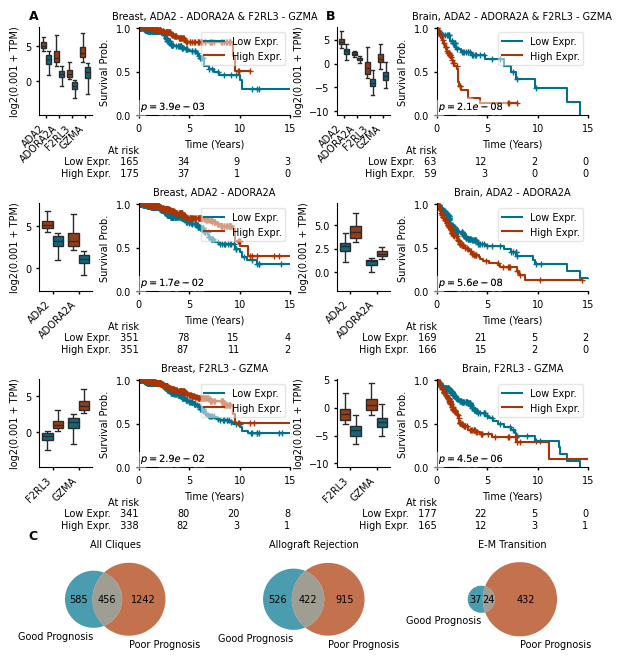

In [15]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import re

fs = 7
smallfs = 7

fig, axs = plt.subplot_mosaic(
    '''
    aAAdDD
    bBBeEE
    cCCfFF
    xxyyzz
    ''',
    figsize=(7.08, 8.)
)
fig.subplots_adjust(hspace=1., wspace=0.9)

#######################
# First set of survival plots

#survival_df = pd.read_csv('/home/lnemati/pathway_crosstalk/data/survival_data/tissues/' + tissue1.lower().replace(' ', '_') + '.csv', index_col=0)
survival_df = survival_df1
surv_axes = [
    (axs['a'], axs['A']),
    (axs['b'], axs['B']),
    (axs['c'], axs['C']),
]
plot_all_3(interactions, tissue1, survival_df, surv_axes, fs=fs, smallfs=smallfs, censors_size=5)

#######################
# Second set of survival plots

#survival_df = pd.read_csv('/home/lnemati/pathway_crosstalk/data/survival_data/tissues/' + tissue2.lower().replace(' ', '_') + '.csv', index_col=0)
survival_df = survival_df2
surv_axes = [
    (axs['d'], axs['D']),
    (axs['e'], axs['E']),
    (axs['f'], axs['F']),
]
plot_all_3(interactions, tissue2, survival_df, surv_axes, fs=fs, smallfs=smallfs, censors_size=5)

#######################
# Venn Diagrams

# Extract gene sets
allograft_genes = hallmarks['HALLMARK_ALLOGRAFT_REJECTION']
em_genes = hallmarks['HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION']

cliques['all_genes'] = cliques.interaction.apply(lambda x: re.split(r'[+_&]', x))

good_cliques = set(cliques.query('hr < 1').interaction)
poor_cliques = set(cliques.query('hr > 1').interaction)

# Allograft overlap
allograft_cliques = cliques[cliques['all_genes'].apply(lambda x: len(allograft_genes.intersection(x)) > 0)].interaction
good_allograft = good_cliques.intersection(allograft_cliques)
poor_allograft = poor_cliques.intersection(allograft_cliques)

# E-M transition overlap
em_cliques = cliques[cliques['all_genes'].apply(lambda x: len(em_genes.intersection(x)) > 0)].interaction
good_em = good_cliques.intersection(em_cliques)
poor_em = poor_cliques.intersection(em_cliques)

for key, dataset in zip(['x', 'y', 'z'], [
    (good_cliques, poor_cliques, 'All Cliques'),
    (good_allograft, poor_allograft, 'Allograft Rejection'),
    (good_em, poor_em, 'E-M Transition'),
]):
    ax = axs[key]
    plt.sca(ax)

    v = venn2(
        [dataset[0], dataset[1]],
        set_labels=('Good Prognosis', 'Poor Prognosis'),
        set_colors=(ncolor, tcolor),
        alpha=0.7
    )

    # ---- FIX: apply your font size ----
    for text in v.set_labels:
        if text:
            text.set_fontsize(fs)

    for text in v.subset_labels:
        if text:
            text.set_fontsize(fs)

    ax.set_title(dataset[2], fontsize=fs)

#######################
# Annotate figure
fig.text(0.11, 0.89,  'A', fontsize=fs+2, fontweight='bold')
fig.text(0.53, 0.89,  'B', fontsize=fs+2, fontweight='bold')
fig.text(0.11, 0.24,  'C', fontsize=fs+2, fontweight='bold')

# -----------------------------
# Save
# -----------------------------
name = 'S5'
figures_dir = '/home/lnemati/pathway_crosstalk/results/figures/new_figures'
os.makedirs(os.path.join(figures_dir, name), exist_ok=True)

plt.savefig(os.path.join(figures_dir, name, name) + '.pdf', bbox_inches='tight', dpi=300)
plt.savefig(os.path.join(figures_dir, name, name) + '.png', bbox_inches='tight', dpi=300)

plt.show()
